In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
# sys.path.append(r'c:/Users/sebas/MalariaProject/')
sys.path.append(r'/home/sgaviria/MalariaProject/')

from src import *

# from params_v4 import KMCParams_v4
# from lattice_v4 import LatticeSOS_v4
# from bkl_v4 import KMC_BKL_v4
# from plotter import Plotter
#from src import KMCParams, LatticeSOS, KMC_BKL, Plotter, KMCParams_v4, LatticeSOS_v4, KMC_BKL_v4

In [3]:
times_isot = np.arange(0, 4.5, 0.5)

In [28]:
L_isot = LatticeSOS_v4(size=(50, 50), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_isot.initialize(mode="seeds", max_height=1, n_seeds=200)

params_isot = KMCParams_v4(
K0_plus= 1.1671806264584635, #0.211,#
K_inc_plus=0.5069325183371898,
E_pb_over_kT_x=1.2704636027368605,
E_pb_over_kT_y=2.19936039,
phi_over_kT= 1.4792478012079329, #3.76, #1.4792478012079329, #
delta_x=1.7789686274068774,
delta_y=1.3,
V=0.9943756704678864,
C_eq=6.66285823642452,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc_isot = KMC_BKL_v4(
    lattice=L_isot,
    params=params_isot,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=50,
    #n_seeds=100,
    constant_concentration=True,  # batch dinámico
)

In [29]:
snaps_isot, stats_isot = kmc_isot.run(t_end=times_isot[-1], snapshot_times=times_isot)

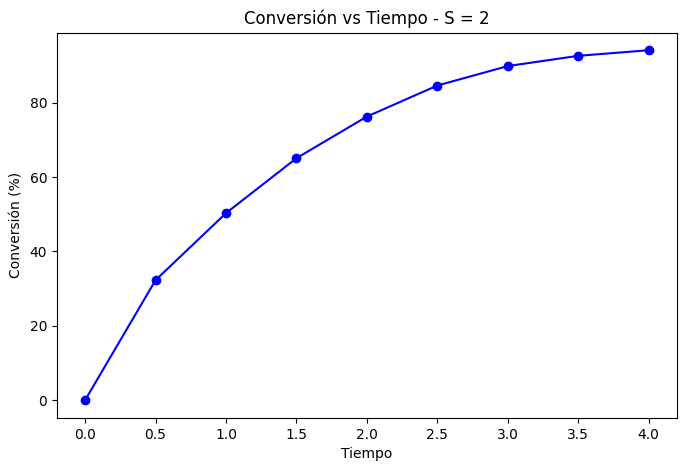

In [30]:
plots = Plotter(kmc_isot)
#plots1 = Plotter(kmc1)
#plots2 = Plotter(kmc2)

plots.plot_conversion(snaps_isot, title=f"Conversión vs Tiempo - S = 2")
#plt.plot(data_txt["Tiempo"], data_txt["Porcentaje"], label="Beta-hematina", marker="s")
#plots1.plot_conversion(snaps1, title=r"Conversión vs Tiempo - S = 2 - $ \phi = E_{pb}/2$")
#plots2.plot_conversion(snaps2, title=r"Conversión vs Tiempo - S = 2 - $ \phi = 0.35*E_{pb}$")
#plots2.crystal_growth_gif(snaps2, save_path=fr"c:\Users\sebas\MalariaProject\results\crystal_growth_S2_1.gif", title_prefix = f"Crystal Growth - S=2")
    

🧩 Snapshot seleccionado: t=4.000


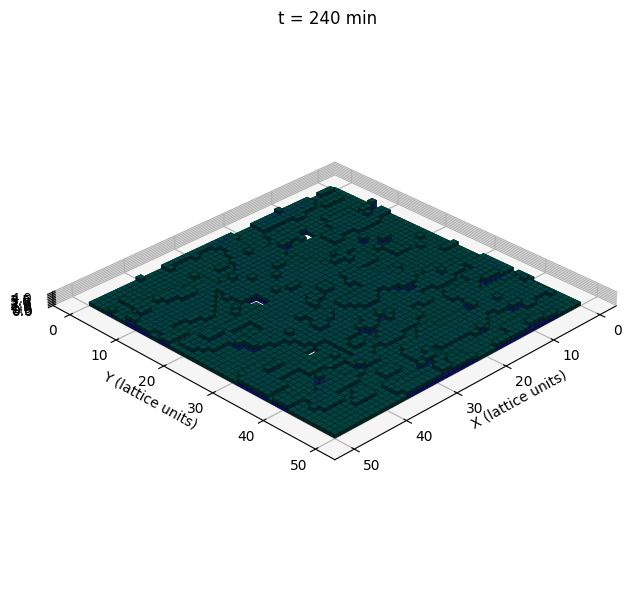

In [47]:
plotter = Plotter_v2(kmc_isot)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_isot,
    t_snapshot=times_isot[8],
    title=f"t = {times_isot[8]*60:.0f} min"
)

In [4]:
import pandas as pd

archivo = r"/home/sgaviria/MalariaProject/notebooks/beta-hematina.txt"

data_txt = pd.read_csv(archivo, sep="\s+", header=None, names=["Tiempo", "Porcentaje", "Error"])

In [6]:
import pandas as pd

conv80_1 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_1_seed_123/conversion_history.csv')
conv80_2 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_2_seed_123/conversion_history.csv')
#conv80_3 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_3_seed_123/conversion_history.csv')
#conv80_4 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_4_seed_123/conversion_history.csv')
#conv80_5 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_5_seed_123/conversion_history.csv')
#conv80_6 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_6_seed_123/conversion_history.csv')

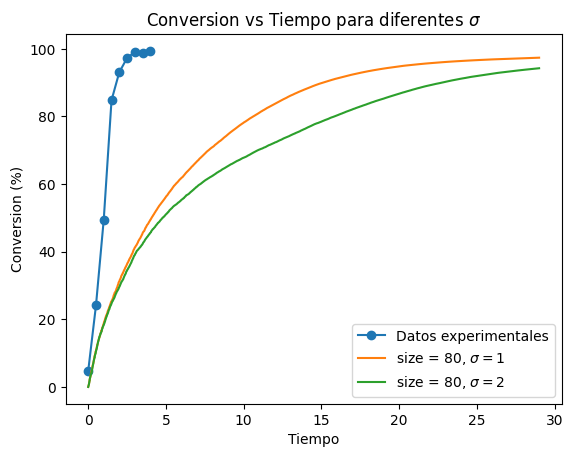

In [7]:
plt.plot(data_txt["Tiempo"], data_txt["Porcentaje"], label="Datos experimentales", marker="o")
plt.plot(conv80_1['time'], conv80_1['conversion'], label=r'size = 80, $\sigma=1$')
plt.plot(conv80_2['time'], conv80_2['conversion'], label=r'size = 80, $\sigma=2$')
#plt.plot(conv80_3['time'], conv80_3['conversion'], label=r'size = 80, $\sigma=3$')
#plt.plot(conv80_4['time'], conv80_4['conversion'], label=r'size = 80, $\sigma=4$')
#plt.plot(conv80_5['time'], conv80_5['conversion'], label=r'size = 80, $\sigma=5$')
#plt.plot(conv80_6['time'], conv80_6['conversion'], label=r'size = 80, $\sigma=6$')
plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Conversion (%)')
plt.title('Conversion vs Tiempo para diferentes $\sigma$')
plt.show()

In [10]:
times_ani_ab_ = np.arange(0, 24, 1)

L_ani_ab_ = LatticeSOS_v4(size=(30, 30), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_ani_ab_.initialize(mode="seeds", max_height=1, n_seeds=15)

params_ani_ab_ = KMCParams_v4(
K0_plus= 0.2116718, #0.211,#
K_inc_plus=0.5069325183371898,
E_pb_over_kT_x=0.76085943,
E_pb_over_kT_y=2.19936039,
phi_over_kT= 1.3792478012079329, #3.76, #1.4792478012079329, #
delta_x=0.3,
delta_y=1.3,
V=1,
C_eq=15.0,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc_ani_ab_ = KMC_BKL_v4(
    lattice=L_ani_ab_,
    params=params_ani_ab_,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=30,
    #n_seeds=100,
    constant_concentration=True,  # batch dinámico
)

In [11]:
snaps_ani_ab_, stats_ani_ab_ = kmc_ani_ab_.run(t_end=times_ani_ab_[-1], snapshot_times=times_ani_ab_)

🧩 Snapshot seleccionado: t=23.000


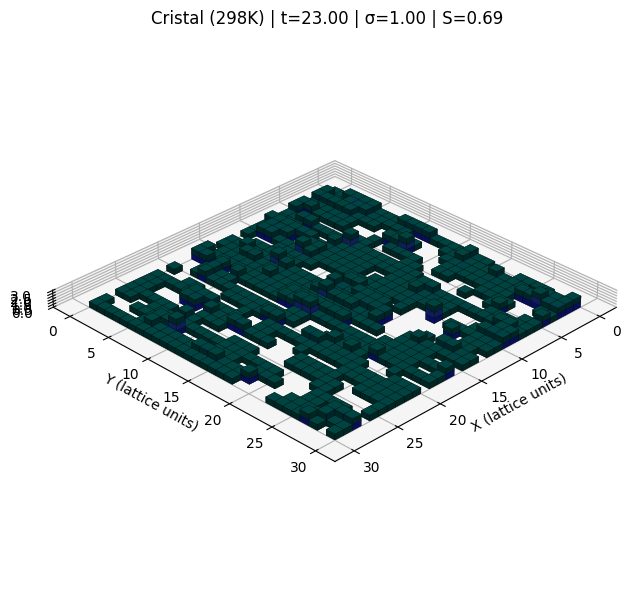

In [12]:
plotter = Plotter_v2(kmc_ani_ab_)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_ani_ab_,
    t_snapshot=times_ani_ab_[-1],
)

In [4]:
from pathlib import Path

root = Path.cwd().resolve()
# Carpeta de salida para GIFs
out_dir = root / "results" / "modelos_gifs"
out_dir.mkdir(parents=True, exist_ok=True)

In [5]:
import pandas as pd

archivo = r"C:\Users\sebas\MalariaProject\data\beta-hematina.txt"

data_txt = pd.read_csv(archivo, sep="\s+", header=None, names=["Tiempo", "Porcentaje", "Error"])

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\sebas\\MalariaProject\\data\\beta-hematina.txt'

In [5]:
#times = np.linspace(0, 300, 20)
times_txt = np.array(data_txt['Tiempo'])
all_times = np.array(list(set(times_txt/5) | set(times_txt/4) | set(times_txt/2) | set(times_txt)))

# **Modelo 3D isotropico sin solvente (concentracion dinamica)**

In [4]:
params_v4 = KMCParams_v4(
    #T=300,
    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT_x=1.2704636027368605,
    E_pb_over_kT_y=1.2704636027368605,
    phi_over_kT=1.4792478012079329,
    delta_x=1.7789686274068774,
    delta_y=1.7789686274068774,
    V=0.789, #V=0.9943756704678864,
    C_eq=171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

In [5]:
L = LatticeSOS_v4(size=[30, 30], seed=42)
L.initialize("flat")

kmc_v4 = KMC_BKL_v4(L, params_v4, N_bulk0=2000, rng_seed=123, time_scale=70, n_seeds=100)
#kmc1 = KMC_BKL(L, params1, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)
#kmc2 = KMC_BKL(L, params2, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)

t0 = time.perf_counter()
#snaps = kmc_v4.run(t_end=times_txt[-1], snapshot_times=times_txt)
# Ejecutar simulación y obtener stats
snaps, stats = kmc_v4.run(t_end=times_txt[-1], snapshot_times=times_txt)
#snaps1 = kmc1.run(t_end=times[-1], snapshot_times=times)
#snaps2 = kmc2.run(t_end=times[-1], snapshot_times=times)
t1 = time.perf_counter()
tiempo = t1 - t0

print(f"\nTiempo de ejecución para tamaño {L.size}: {(tiempo)/60:.3f} minutos")


Tiempo de ejecución para tamaño (30, 30): 10.730 minutos


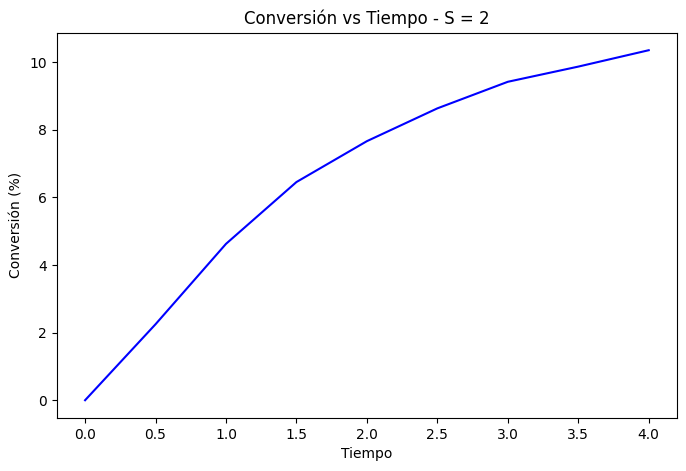

In [6]:
plots = Plotter(kmc_v4)
plots.plot_conversion(snaps, title=f"Conversión vs Tiempo - S = 2")

## **Otro caso particular**

In [5]:
# Modelo 3D isotropico sin solvente con concentracion dinamica
lat3d_iso_dyn = LatticeSOS_v4((50, 50), seed=1)
lat3d_iso_dyn.initialize(mode="flat")

# Puntos de tiempo para snapshots
snapshot_times_3d_iso_dyn = np.linspace(0.0, 20.0, 20)

# Parametros isotropicos (x = y)
p3d_iso = KMCParams_v4(
    K0_plus=2.13,
    E_pb_over_kT_x=1.5,
    E_pb_over_kT_y=1.5,
    phi_over_kT=4.0,
    delta_x=0.3,
    delta_y=0.3,
    V=1.0e5,
    C_eq=1.0e-2,
    fixed_sigma=None,
    solvent_ads_factor=1.0,
    solvent_des_factor=1.0,
    solvent_mig_factor=1.0,
 )

# Ejecuta con concentracion dinamica y solvente desactivado
kmc3d_iso_dyn = KMC_BKL_v4(
    lattice=lat3d_iso_dyn,
    params=p3d_iso,
    N_bulk0=5000,
    rng_seed=1,
    time_scale=50.0,
    n_seeds=10,
    debug=False,
    constant_concentration=False,
    use_solvent=False,
 )
snaps_3d_iso_dyn, stats_3d_iso_dyn = kmc3d_iso_dyn.run(
    t_end=20.0, snapshot_times=snapshot_times_3d_iso_dyn, max_events=5000
 )
print("3D isotropico dinamico:", stats_3d_iso_dyn["total_time"], stats_3d_iso_dyn["event_counts"])

3D isotropico dinamico: 3.3963777446272805 {'adsorption': 1789, 'desorption': 1008, 'migration': 2203, 'incorporation': 0}


🧩 Usando último snapshot disponible: t=20.000 (conv=0.00%)


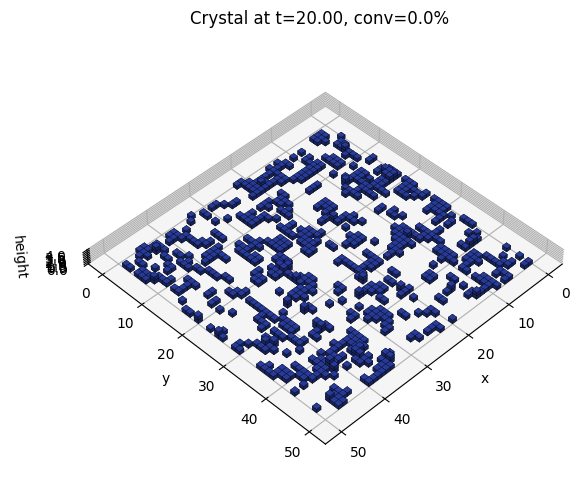

💾 GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_isotropico_dinamico.gif
GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_isotropico_dinamico.gif


In [7]:
# Visualizacion 3D: ultimo snapshot y GIF
plotter_3d_iso_dyn = Plotter(kmc3d_iso_dyn)
if snaps_3d_iso_dyn:
    plotter_3d_iso_dyn.plot_crystal_3d(
        mode="voxel",
        snapshots=snaps_3d_iso_dyn,
    )
    gif_path = out_dir / "3d_isotropico_dinamico.gif"
    try:
        plotter_3d_iso_dyn.crystal_growth_gif(
            snaps_3d_iso_dyn,
            save_path=str(gif_path),
            mode="voxel",
            fps=8,
            every_n=1,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

# **Modelo 3D isotropico sin solvente (concentracion estatica)**

In [8]:
# Modelo 3D isotropico sin solvente con concentracion estatica
lat3d_iso_static = LatticeSOS_v4((50, 50), seed=2)
lat3d_iso_static.initialize(mode="flat")

# Puntos de tiempo para snapshots
snapshot_times_3d_iso_static = np.linspace(0.0, 20.0, 20)

# Parametros isotropicos (x = y)
p3d_iso_static = KMCParams_v4(
    K0_plus=2.13,
    E_pb_over_kT_x=1.5,
    E_pb_over_kT_y=1.5,
    phi_over_kT=4.0,
    delta_x=0.3,
    delta_y=0.3,
    V=1.0e5,
    C_eq=1.0e-2,
    fixed_sigma=2.0,
    solvent_ads_factor=1.0,
    solvent_des_factor=1.0,
    solvent_mig_factor=1.0,
 )

# Ejecuta con concentracion estatica y solvente desactivado
kmc3d_iso_static = KMC_BKL_v4(
    lattice=lat3d_iso_static,
    params=p3d_iso_static,
    N_bulk0=5000,
    rng_seed=2,
    time_scale=50.0,
    n_seeds=10,
    debug=False,
    constant_concentration=True,
    use_solvent=False,
 )
snaps_3d_iso_static, stats_3d_iso_static = kmc3d_iso_static.run(
    t_end=20.0, snapshot_times=snapshot_times_3d_iso_static, max_events=5000
 )
print("3D isotropico estatico:", stats_3d_iso_static["total_time"], stats_3d_iso_static["event_counts"])

3D isotropico estatico: 4.554312507695059 {'adsorption': 1611, 'desorption': 1077, 'migration': 2312, 'incorporation': 0}


🧩 Usando último snapshot disponible: t=20.000 (conv=0.00%)


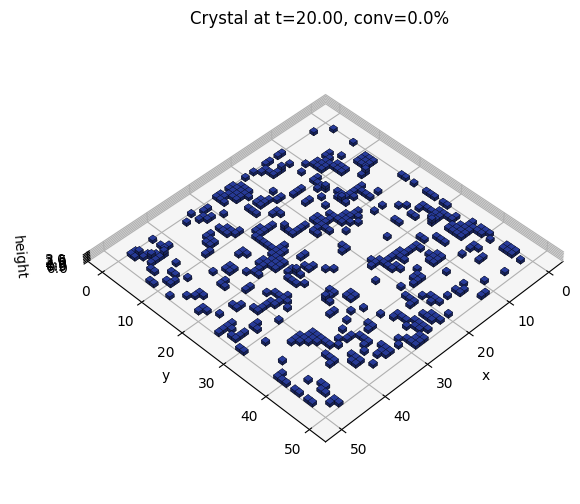

💾 GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_isotropico_estatico.gif
GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_isotropico_estatico.gif


In [9]:
# Visualizacion 3D: ultimo snapshot y GIF
plotter_3d_iso_static = Plotter(kmc3d_iso_static)
if snaps_3d_iso_static:
    plotter_3d_iso_static.plot_crystal_3d(
        mode="voxel",
        snapshots=snaps_3d_iso_static,
    )
    gif_path = out_dir / "3d_isotropico_estatico.gif"
    try:
        plotter_3d_iso_static.crystal_growth_gif(
            snaps_3d_iso_static,
            save_path=str(gif_path),
            mode="voxel",
            fps=8,
            every_n=1,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

# **Modelo 3D anisotropico sin solvente (concentracion estatica)**

In [10]:
# Modelo 3D anisotropico sin solvente con concentracion estatica
lat3d_aniso_static = LatticeSOS_v4((50, 50), seed=3)
lat3d_aniso_static.initialize(mode="flat", n_seeds=100)

# Puntos de tiempo para snapshots
snapshot_times_3d_aniso_static = np.linspace(0.0, 10.0, 10)

# Parametros anisotropicos con contraste marcado
p3d_aniso_static = KMCParams_v4(
    K0_plus=11.671806264584635,
    E_pb_over_kT_x= 0.76085943, #0.30,
    E_pb_over_kT_y= 2.19936039, #1.5,
    phi_over_kT= 1.4792478012079329, #1.60,
    delta_x= 1.8, #0.2,
    delta_y= 0.1, #0.7,
    V=1.,
    C_eq=12.0,
    fixed_sigma=2.0,
    # solvent_ads_factor=1.0,
    # solvent_des_factor=1.0,
    # solvent_mig_factor=1.0,
 )



# Ejecuta con concentracion estatica y solvente desactivado
kmc3d_aniso_static = KMC_BKL_v4(
    lattice=lat3d_aniso_static,
    params=p3d_aniso_static,
    N_bulk0=2000,
    rng_seed=3,
    time_scale=10.0,
    n_seeds=0,
    debug=False,
    constant_concentration=True,
    use_solvent=False,
 )
snaps_3d_aniso_static, stats_3d_aniso_static = kmc3d_aniso_static.run(
    t_end=20.0, snapshot_times=snapshot_times_3d_aniso_static, max_events=5000
 )
print("3D anisotropico estatico:", stats_3d_aniso_static["total_time"], stats_3d_aniso_static["event_counts"])

3D anisotropico estatico: 0.20624569996089714 {'adsorption': 4127, 'desorption': 281, 'migration': 592, 'incorporation': 0}


🧩 Usando último snapshot disponible: t=10.000 (conv=0.00%)


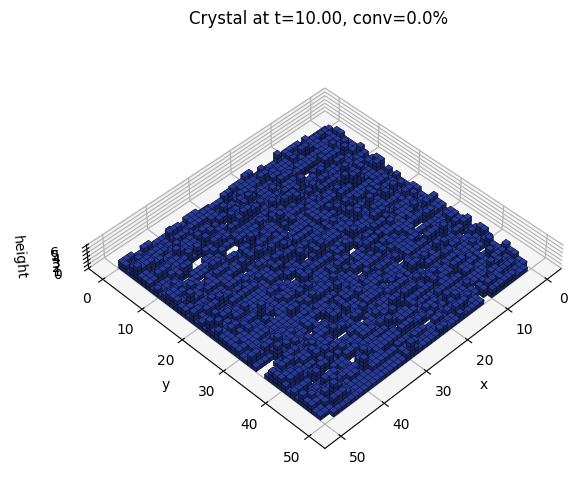

💾 GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_anisotropico_estatico.gif
GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_anisotropico_estatico.gif


In [12]:
# Visualizacion 3D: ultimo snapshot y GIF
plotter_3d_aniso_static = Plotter(kmc3d_aniso_static)
if snaps_3d_aniso_static:
    plotter_3d_aniso_static.plot_crystal_3d(
        mode="voxel",
        snapshots=snaps_3d_aniso_static,
    )
    gif_path = out_dir / "3d_anisotropico_estatico.gif"
    try:
        plotter_3d_aniso_static.crystal_growth_gif(
            snaps_3d_aniso_static,
            save_path=str(gif_path),
            mode="voxel",
            fps=20,
            every_n=1,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

# **Modelo 3D isotropico con solvente (concentracion estatica)**

In [ ]:
# Modelo 3D isotropico con solvente con concentracion estatica
lat3d_iso_sol = LatticeSOS_v4((50, 50), seed=4)
lat3d_iso_sol.initialize(mode="flat")

# Puntos de tiempo para snapshots
snapshot_times_3d_iso_sol = np.linspace(0.0, 20.0, 20)

# Parametros isotropicos con factores de solvente
p3d_iso_sol = KMCParams_v4(
    K0_plus=0.213,
    E_pb_over_kT_x=1.5,
    E_pb_over_kT_y=1.5,
    phi_over_kT=4.0,
    delta_x=0.3,
    delta_y=0.3,
    V=1.0e5,
    C_eq=1.0e-2,
    fixed_sigma=2.0,
    solvent_ads_factor=0.7,
    solvent_des_factor=1.2,
    solvent_mig_factor=0.8,
 )

# Ejecuta con concentracion estatica y solvente activado
kmc3d_iso_sol = KMC_BKL_v4(
    lattice=lat3d_iso_sol,
    params=p3d_iso_sol,
    N_bulk0=10000,
    rng_seed=4,
    time_scale=50.0,
    n_seeds=10,
    debug=False,
    constant_concentration=True,
    use_solvent=True,
 )
snaps_3d_iso_sol, stats_3d_iso_sol = kmc3d_iso_sol.run(
    t_end=20.0, snapshot_times=snapshot_times_3d_iso_sol, max_events=5000
 )
print("3D isotropico con solvente:", stats_3d_iso_sol["total_time"], stats_3d_iso_sol["event_counts"])

3D isotropico con solvente: 0.014520576864722032 {'adsorption': 1620, 'desorption': 1376, 'migration': 2004, 'incorporation': 0}


🧩 Usando último snapshot disponible: t=20.000 (conv=0.00%)


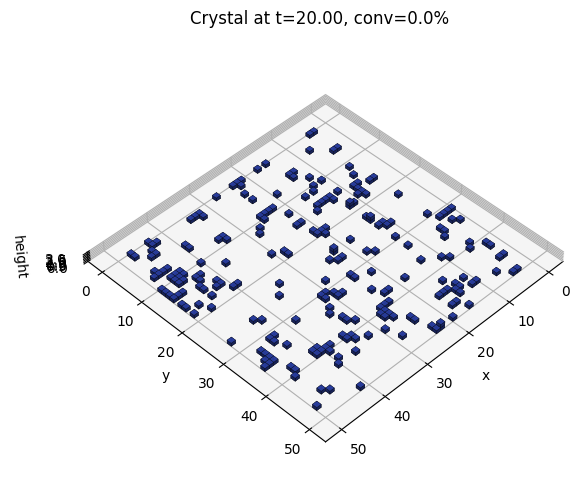

💾 GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_isotropico_con_solvente.gif
GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_isotropico_con_solvente.gif


In [18]:
# Visualizacion 3D: ultimo snapshot y GIF
plotter_3d_iso_sol = Plotter(kmc3d_iso_sol)
if snaps_3d_iso_sol:
    plotter_3d_iso_sol.plot_crystal_3d(
        mode="voxel",
        snapshots=snaps_3d_iso_sol,
    )
    gif_path = out_dir / "3d_isotropico_con_solvente.gif"
    try:
        plotter_3d_iso_sol.crystal_growth_gif(
            snaps_3d_iso_sol,
            save_path=str(gif_path),
            mode="voxel",
            fps=8,
            every_n=1,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

# **Modelo 3D anisotropico con solvente (concentracion estatica)**

In [21]:
# Modelo 3D anisotropico con solvente con concentracion estatica
lat3d_aniso_sol = LatticeSOS_v4((50, 50), seed=5)
lat3d_aniso_sol.initialize(mode="flat")

# Puntos de tiempo para snapshots
snapshot_times_3d_aniso_sol = np.linspace(0.0, 20.0, 20)

# Parametros anisotropicos con solvente y contraste marcado
p3d_aniso_sol = KMCParams_v4(
    K0_plus=0.213,
    E_pb_over_kT_x=2.0,
    E_pb_over_kT_y=0.5,
    phi_over_kT=4.0,
    delta_x=0.6,
    delta_y=0.1,
    V=1.0e5,
    C_eq=1.0e-2,
    fixed_sigma=5.0,
    solvent_ads_factor=0.65,
    solvent_des_factor=1.3,
    solvent_mig_factor=0.75,
 )

# Ejecuta con concentracion estatica y solvente activado
kmc3d_aniso_sol = KMC_BKL_v4(
    lattice=lat3d_aniso_sol,
    params=p3d_aniso_sol,
    N_bulk0=10000,
    rng_seed=5,
    time_scale=50.0,
    n_seeds=10,
    debug=False,
    constant_concentration=True,
    use_solvent=True,
 )
snaps_3d_aniso_sol, stats_3d_aniso_sol = kmc3d_aniso_sol.run(
    t_end=20.0, snapshot_times=snapshot_times_3d_aniso_sol, max_events=5000
 )
print("3D anisotropico con solvente:", stats_3d_aniso_sol["total_time"], stats_3d_aniso_sol["event_counts"])

3D anisotropico con solvente: 20.00454923465179 {'adsorption': 871, 'desorption': 598, 'migration': 689, 'incorporation': 0}


🧩 Usando último snapshot disponible: t=20.000 (conv=0.00%)


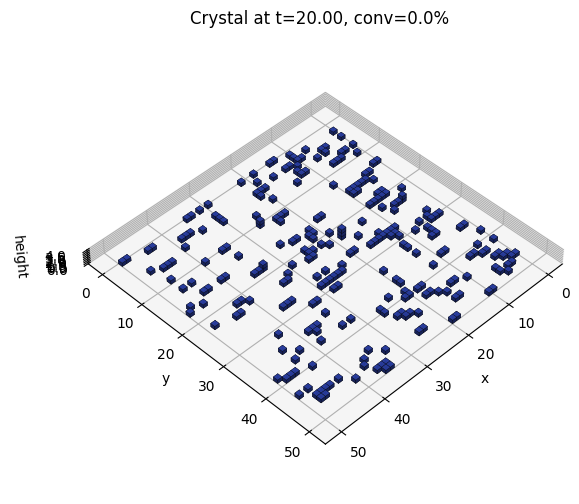

💾 GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_anisotropico_con_solvente.gif
GIF guardado en: C:\Users\sebas\MalariaProject\notebooks\results\modelos_gifs\3d_anisotropico_con_solvente.gif


In [22]:
# Visualizacion 3D: ultimo snapshot y GIF
plotter_3d_aniso_sol = Plotter(kmc3d_aniso_sol)
if snaps_3d_aniso_sol:
    plotter_3d_aniso_sol.plot_crystal_3d(
        mode="voxel",
        snapshots=snaps_3d_aniso_sol,
    )
    gif_path = out_dir / "3d_anisotropico_con_solvente.gif"
    try:
        plotter_3d_aniso_sol.crystal_growth_gif(
            snaps_3d_aniso_sol,
            save_path=str(gif_path),
            mode="voxel",
            fps=8,
            every_n=1,
        )
        print(f"GIF guardado en: {gif_path}")
    except Exception as exc:
        print("No se pudo guardar el GIF:", exc)
else:
    print("No hay snapshots para visualizar.")

# **Prueba simulación**

In [12]:
# Ejecucion corta para validar conversion en concentracion constante
# Usa parametros ya definidos con incorporacion activa
if "params_v4" not in globals():
    # Recrear params_v4 con los valores del notebook
    params_v4 = KMCParams_v4(
        K0_plus=11.671806264584635,
        K_inc_plus=0.5069325183371898,
        E_pb_over_kT_x= 0.76085943, #1.2704636027368605,
        E_pb_over_kT_y= 2.19936039, #1.2704636027368605,
        phi_over_kT=1.4792478012079329,
        delta_x= 1.7789686274068774,
        delta_y= 1.7789686274068774,
        V=0.789,
        C_eq=171.856385685984442,
        S_floor=-5.0,
        S_ceil=8.0,
    )

print("K_inc_plus usado:", params_v4.K_inc_plus)

lat_cc = LatticeSOS_v4((30, 30), seed=123)
lat_cc.initialize(mode="seeds")

kmc_cc = KMC_BKL_v4(
    lattice=lat_cc,
    params=params_v4,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=400.0,
    n_seeds=100,
    debug=False,
    constant_concentration=True,
    use_solvent=False,
 )

snapshot_times_cc = np.linspace(0, 6, 6)
snaps_cc, stats_cc = kmc_cc.run(
    t_end=6, snapshot_times=snapshot_times_cc, max_events=5000
 )

# Resumen corto de conversion
conv_series = stats_cc["conversion_history"]
print("Eventos:", stats_cc["total_events"])
if conv_series:
    conv_start = conv_series[0][1]
    conv_end = conv_series[-1][1]
    print("Conversion inicial/final:", conv_start, conv_end)
    print("Delta conversion:", conv_end - conv_start)
    sample_step = max(1, len(conv_series) // 5)
    print("Muestra (t, conversion%):", conv_series[::sample_step])

K_inc_plus usado: 0.5069325183371898
Eventos: 4898
Conversion inicial/final: 0.0 10.39426523297491
Delta conversion: 10.39426523297491
Muestra (t, conversion%): [(0.0009867200215283177, 0.0), (1.3026557976103923, 1.6232169208066896), (2.4500753362630623, 4.168663152850982), (3.5710624107128637, 6.585707613264829), (4.732660902511645, 8.508691674290942), (5.996778629927598, 10.354101299865532)]


In [ ]:
# Graficacion de conversion para el caso corto en concentracion constante
if "snaps_cc" in globals() and snaps_cc:
    plotter_cc = Plotter(kmc_cc)
    plotter_cc.plot_conversion(
        snaps_cc,
        title="Conversion vs Tiempo - concentracion constante (test corto)",
    )
else:
    print("No hay snapshots disponibles para graficar conversion.")

No hay snapshots disponibles para graficar conversion.


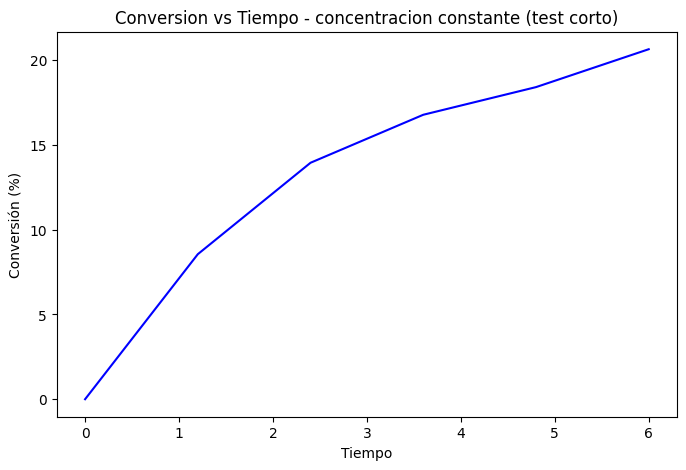

In [20]:
# Graficacion de conversion para el caso corto en concentracion constante
if "snaps_cc" in globals() and snaps_cc:
    plotter_cc = Plotter(kmc_cc)
    plotter_cc.plot_conversion(
        snaps_cc,
        title="Conversion vs Tiempo - concentracion constante (test corto)",
    )
else:
    print("No hay snapshots disponibles para graficar conversion.")